1.	Deberás utilizar el archivo llamado bank_marketing.csv. con los datos de problema.
2.	Utilizar el archivo bank-names.txt para obtener información de cada una de las variables.
3.	Crear un proyecto tipo Jupyter Notebook en Google-Colab llamado Solucion_Reto_SC_63_<nombre_y_apellido_del_estudiante>.ipynb.
4.	Incluye las librerías que consideres adecuadas y carga los datos del archivo en una variable llamada “data”.


In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn import svm
import pickle

In [45]:
data= pd.read_csv("/content/sample_data/0.xozu243mego0.145c4n51y90bbank_marketing_RETO_DS_AS.csv")

5.	Obtener la información de dicha base de datos que incluya el número de registros, el total de variables, el tipo de cada variable, la cantidad de datos perdidos de cada variable en caso de que existan.

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   object
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   object
 7   loan       9000 non-null   object
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   object
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
 16  y          9000 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.2+ MB


6.	Transforma las variables categóricas de manera que puedan ser tratadas numéricamente. Justifica si utilizas LabelEncoder o OneHotEcoder.

In [47]:
# Se convierten todas las variables categóricas de entrada a varias columnas con OneHotEncoder para que el programa las pueda analizar.
#Se desecha la primera columna para prevenir la multicolinealidad.
#Se elimina la variable "day" al tener una distribución constante y no aportar tanta información.
#Se utiliza label encoder para la variable "y" al ser la de salida.
df=pd.DataFrame(data)
df.drop("day", axis=1, inplace=True)
categorical_columns = ["job", "marital", "education", "default", "housing", "loan", "contact","campaign" ,"poutcome", "month"]
encoder = OneHotEncoder(sparse_output=False, drop="first")
one_hot_encoded = encoder.fit_transform(df[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_encoded = pd.concat([df, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)
le=LabelEncoder()
df_encoded["y"]=le.fit_transform(df_encoded["y"])
#print(f"Encoded Employee data : \n{df_encoded}")
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9000 non-null   int64  
 1   balance              9000 non-null   int64  
 2   duration             9000 non-null   int64  
 3   pdays                9000 non-null   int64  
 4   previous             9000 non-null   int64  
 5   y                    9000 non-null   int64  
 6   job_blue-collar      9000 non-null   float64
 7   job_entrepreneur     9000 non-null   float64
 8   job_housemaid        9000 non-null   float64
 9   job_management       9000 non-null   float64
 10  job_retired          9000 non-null   float64
 11  job_self-employed    9000 non-null   float64
 12  job_services         9000 non-null   float64
 13  job_student          9000 non-null   float64
 14  job_technician       9000 non-null   float64
 15  job_unemployed       9000 non-null   f

7.	Transforma las variables numéricas en los casos que se tenga algún tipo de sesgo.

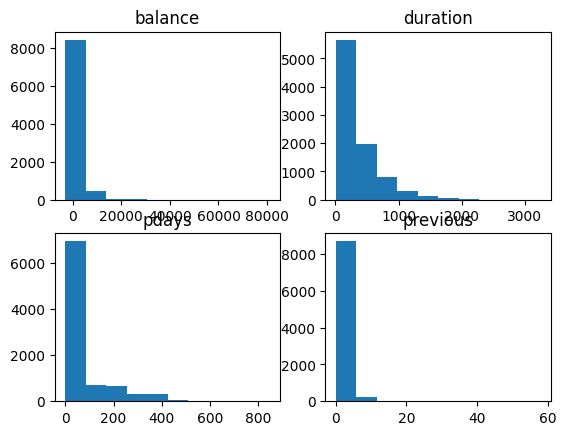

In [48]:
#Las variables definidas como categóricas en el apartado anterior y que se les aplicó el OneHotEncoder ("job", "marital", "education", "default", "housing", "loan", "contact","campaign" ,"poutcome","month", "y") no se le aplican transformaciones porque sus valores deben ser 0 o 1.)

figure, axis = plt.subplots(2, 2)
axis[0, 0].hist(df_encoded["balance"])
axis[0,0].set_title("balance")

axis[0, 1].hist(df_encoded["duration"])
axis[0,1].set_title("duration")

axis[1, 0].hist(df_encoded["pdays"])
axis[1,0].set_title("pdays")

axis[1, 1].hist(df_encoded["previous"])
axis[1,1].set_title("previous")

plt.show()
# Transformar balance, duration, pdays, previous a una distribución gaussiana
#days tiene una distribución relativamente constante por lo que se mantiene así.


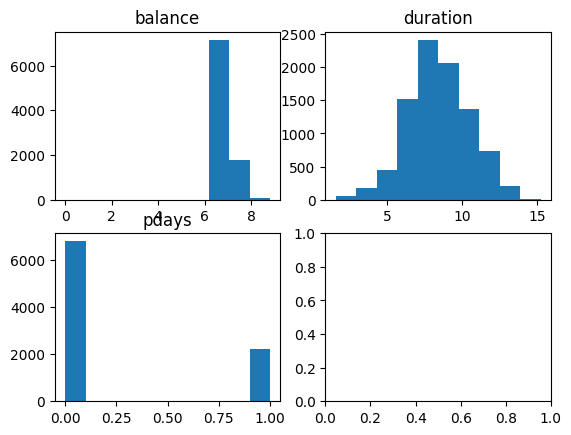

In [49]:
#Se determina si el balance de la cuenta es positivo o no.
#Se utilizan librerias para transformar las variables para asegurar su calidad.
df_encoded["balance_est"] = (df_encoded["balance"]-df_encoded["balance"].min()+1)
df_encoded["pos_balance"] = df_encoded["balance"].apply(lambda x: 0 if x < 0 else 1)
box = stats.boxcox(df_encoded["balance_est"])
df_encoded["balance_norm"] = box[0]
df_encoded["duration_transformed"] = stats.boxcox(df_encoded["duration"]+1)[0]
df_encoded["contacted"] = df_encoded["pdays"].apply(lambda x: 0 if x == -1 else 1)

figure, axis = plt.subplots(2, 2)
axis[0, 0].hist(df_encoded["balance_norm"])
axis[0,0].set_title("balance")

axis[0, 1].hist(df_encoded["duration_transformed"])
axis[0,1].set_title("duration")

axis[1, 0].hist(df_encoded["contacted"])
axis[1,0].set_title("pdays")


plt.show()

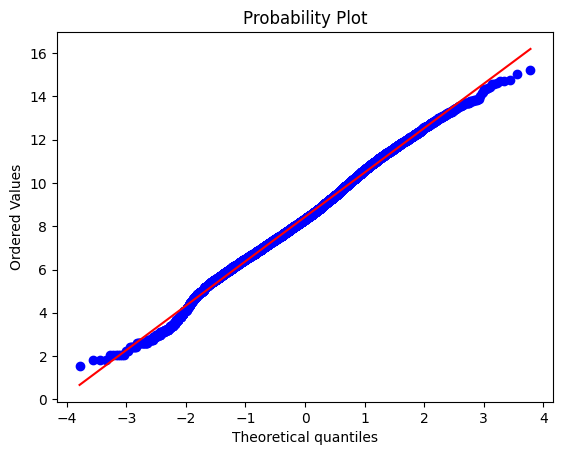

In [50]:
#Se verifica la normalidad
stats.probplot(df_encoded["duration_transformed"], dist="norm", plot=plt)
plt.show()

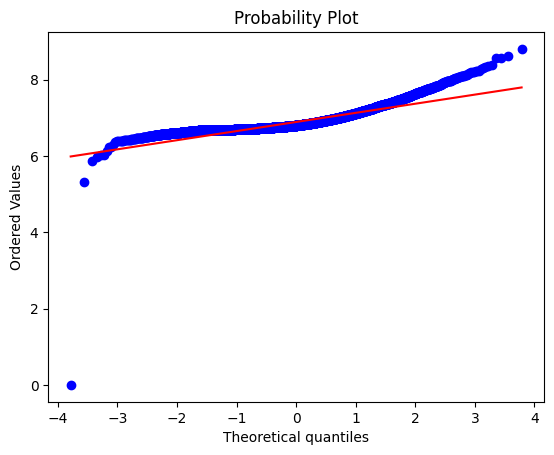

In [51]:
#Se verifica la normalidad, se identifican outliers pero se mantienen.
stats.probplot(df_encoded["balance_norm"], dist="norm", plot=plt)
plt.show()

In [52]:
#Se estandarizan las variables numéricas
#df_encoded["duration_transformed"] = (df_encoded["duration_transformed"] - df_encoded["duration_transformed"].mean())/df_encoded["duration_transformed"].std()
#df_encoded["balance_norm"] = (df_encoded["balance_norm"] - df_encoded["balance_norm"].mean())/df_encoded["balance_norm"].std()


8.	Considera la variable “y” como la variable de salida y el resto de las variables como las variables de entrada.
9.	Particiona los datos en los conjuntos de entrenamiento, validación y prueba en 60%, 20% y 20%, respectivamente.

In [53]:
#Se eliminan las valiables a las que ya se ses aplicó la transformación y se extraen los nombres de las columnas para verificafr que no estén repetidas.
df_encoded.drop("balance", axis=1, inplace=True)
df_encoded.drop("duration", axis=1, inplace=True)
df_encoded.columns.values.tolist()

['age',
 'pdays',
 'previous',
 'y',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_married',
 'marital_single',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'default_yes',
 'housing_yes',
 'loan_yes',
 'contact_telephone',
 'contact_unknown',
 'campaign_2',
 'campaign_3',
 'campaign_4',
 'campaign_5',
 'campaign_6',
 'campaign_7',
 'campaign_8',
 'campaign_9',
 'campaign_10',
 'campaign_11',
 'campaign_12',
 'campaign_13',
 'campaign_14',
 'campaign_15',
 'campaign_16',
 'campaign_17',
 'campaign_18',
 'campaign_19',
 'campaign_20',
 'campaign_21',
 'campaign_23',
 'campaign_24',
 'campaign_25',
 'campaign_26',
 'campaign_27',
 'campaign_28',
 'campaign_29',
 'campaign_30',
 'campaign_32',
 'campaign_36',
 'campaign_37',
 'campaign_38',
 'campaign_58',
 'poutcome_other',
 'poutcome_success',
 'pou

In [54]:
#Se separa el dataframe en las valiables que se usan para crear el modelo y la variable de salida.
X= df_encoded[['age',
 'pdays',
 'previous',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_married',
 'marital_single',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'default_yes',
 'housing_yes',
 'loan_yes',
 'contact_telephone',
 'contact_unknown',
 'campaign_2',
 'campaign_3',
 'campaign_4',
 'campaign_5',
 'campaign_6',
 'campaign_7',
 'campaign_8',
 'campaign_9',
 'campaign_10',
 'campaign_11',
 'campaign_12',
 'campaign_13',
 'campaign_14',
 'campaign_15',
 'campaign_16',
 'campaign_17',
 'campaign_18',
 'campaign_19',
 'campaign_20',
 'campaign_21',
 'campaign_23',
 'campaign_24',
 'campaign_25',
 'campaign_26',
 'campaign_27',
 'campaign_28',
 'campaign_29',
 'campaign_30',
 'campaign_32',
 'campaign_36',
 'campaign_37',
 'campaign_38',
 'campaign_58',
 'poutcome_other',
 'poutcome_success',
 'poutcome_unknown',
 'month_aug',
 'month_dec',
 'month_feb',
 'month_jan',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep',
 'balance_est',
 'pos_balance',
 'balance_norm',
 'duration_transformed',
 'contacted']]
Y= df_encoded["y"]

X=X.values
Y=Y.values

#Se particionan los datos
x_train, x_validation_and_test, y_train, Y_validation_and_test = train_test_split(X,Y, train_size=.6)
x_validation, x_test, y_validation, y_test = train_test_split(x_validation_and_test,Y_validation_and_test, train_size=.5)

In [55]:
X

array([[ 31.        ,  97.        ,   6.        , ...,   7.12029379,
          8.95580185,   1.        ],
       [ 29.        ,  -1.        ,   0.        , ...,   6.97965955,
          8.37396033,   0.        ],
       [ 41.        ,  -1.        ,   0.        , ...,   7.05730986,
          9.29770428,   0.        ],
       ...,
       [ 44.        ,  -1.        ,   0.        , ...,   7.14546326,
          4.48613077,   0.        ],
       [ 57.        ,  -1.        ,   0.        , ...,   6.79744326,
         12.32416201,   0.        ],
       [ 40.        , 119.        ,   9.        , ...,   6.83538101,
          9.66267627,   1.        ]])

10.	Aplica el modelo Regresión Logística en el conjunto de entrenamiento. Valida el modelo con las predicciones del conjunto de validación y su matriz de confusión. Ajusta los parámetros del modelo hasta obtener tu mejor resultado.

In [56]:
#Se hacen varias pruebas preliminares para ver las características que conviene utilizar en el grid search.
clf1 =LogisticRegression (C=15, penalty="l2", solver="newton-cg", max_iter=1000)
modelo_RL1 = clf1.fit(x_train, y_train)
print("Exactitud (accuracy) con el conjunto de validación= ", modelo_RL1.score(x_validation, y_validation))
pred= modelo_RL1.predict(x_validation)
print("Matriz de confusión: \n", confusion_matrix(y_validation, pred))

Exactitud (accuracy) con el conjunto de validación=  0.8122222222222222
Matriz de confusión: 
 [[874 156]
 [182 588]]


In [57]:
clf2 =LogisticRegression (C=0.1, penalty="l1", solver="saga", max_iter=1500)
modelo_RL2 = clf2.fit(x_train, y_train)
print("Exactitud (accuracy) con el conjunto de validación= ", modelo_RL2.score(x_validation, y_validation))
pred= modelo_RL2.predict(x_validation)
print("Matriz de confusión: \n", confusion_matrix(y_validation, pred))

Exactitud (accuracy) con el conjunto de validación=  0.5705555555555556
Matriz de confusión: 
 [[911 119]
 [654 116]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [58]:
clf3 =LogisticRegression (C=1, penalty="l2", solver="lbfgs", max_iter=2000)
modelo_RL3 = clf3.fit(x_train, y_train)
print("Exactitud (accuracy) con el conjunto de validación= ", modelo_RL3.score(x_validation, y_validation))
pred= modelo_RL3.predict(x_validation)
print("Matriz de confusión: \n", confusion_matrix(y_validation, pred))

Exactitud (accuracy) con el conjunto de validación=  0.8083333333333333
Matriz de confusión: 
 [[873 157]
 [188 582]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [59]:
clf4 =LogisticRegression (C=10, penalty="l1", solver="liblinear", max_iter=1000)
modelo_RL4 = clf4.fit(x_train, y_train)
print("Exactitud (accuracy) con el conjunto de validación= ", modelo_RL4.score(x_validation, y_validation))
pred= modelo_RL4.predict(x_validation)
print("Matriz de confusión: \n", confusion_matrix(y_validation, pred))

Exactitud (accuracy) con el conjunto de validación=  0.8116666666666666
Matriz de confusión: 
 [[877 153]
 [186 584]]


In [60]:
#Se hacen listas con todas las combinaciones de atributos que se quieren probar. Se eligieron al ser los que necesitan tener menos iteraciones para converger además de tener un mejor desempeño.
parameters = {"C": [0.5, 1, 5, 10], "penalty": ("l1", "l2"), "solver": ("liblinear", "newton-cg")}
RL_grid = LogisticRegression(max_iter=1000)
#Se corre un modelo con las iteraciones mencionadas anteriormente.
modelo_RL_grid = GridSearchCV(RL_grid, parameters)
modelo_RL_grid.fit(x_train, np.ravel(y_train))
print(modelo_RL_grid)
#Se guarda el modelo para que sea más rápido recuperarlo para próximas iteraciones
with open ("modelo_RL_grid.pkl", "wb") as f:
  pickle.dump(modelo_RL_grid, f)


GridSearchCV(estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.5, 1, 5, 10], 'penalty': ('l1', 'l2'),
                         'solver': ('liblinear', 'newton-cg')})


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

In [61]:
#Los errores del grid search eran esperados ya que el solver "newton-cg" y la penalización "l1" no son compatibles
#Se imprimen los resultados
print(f"Mejores parámetros {modelo_RL_grid.best_params_} con un score de {modelo_RL_grid.best_score_:0.2f}")


Mejores parámetros {'C': 5, 'penalty': 'l1', 'solver': 'liblinear'} con un score de 0.83


11.	Aplica el modelo Red Neuronal en el conjunto de entrenamiento. Valida el modelo con las predicciones del conjunto de validación y su matriz de confusión. Ajusta los parámetros del modelo hasta obtener tu mejor modelo, entre ellos el número de neuronas y capas ocultas.

In [68]:
#Se hacen varias pruebas preliminares para ver las características que conviene utilizar en el grid search.
modelo_NN_1 = MLPClassifier(hidden_layer_sizes=(38,38), max_iter=1000, activation="logistic", learning_rate="constant", solver="lbfgs" )
modelo_NN_1.fit(x_train, y_train)
print("Exactitud (accuracy) con el conjunto de validacion= ", modelo_NN_1.score(x_validation, y_validation))
pr_NN_1= modelo_NN_1.predict(x_validation)

Exactitud (accuracy) con el conjunto de validacion=  0.5744444444444444


In [69]:
modelo_NN_2 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, activation="relu", solver="adam" )
modelo_NN_2.fit(x_train, y_train)
print("Exactitud (accuracy) con el conjunto de validación= ", modelo_NN_2.score(x_validation, y_validation))
pr_NN_2= modelo_NN_2.predict(x_validation)


Exactitud (accuracy) con el conjunto de validación=  0.42944444444444446


In [70]:
modelo_NN_3 = MLPClassifier(hidden_layer_sizes=(150,150), max_iter=1000, activation="relu", solver="adam" )
modelo_NN_3.fit(x_train, y_train)
print("Exactitud (accuracy) con el conjunto de validación= ", modelo_NN_3.score(x_validation, y_validation))
pr_NN_3= modelo_NN_3.predict(x_validation)


Exactitud (accuracy) con el conjunto de validación=  0.6161111111111112


In [73]:
modelo_NN_4 = MLPClassifier(hidden_layer_sizes=(100,100), max_iter=1000, activation="relu", solver="sgd" )
modelo_NN_4.fit(x_train, y_train)
print("Exactitud (accuracy) con el conjunto de validación= ", modelo_NN_4.score(x_validation, y_validation))
pr_NN_4= modelo_NN_4.predict(x_validation)

Exactitud (accuracy) con el conjunto de validación=  0.5722222222222222


In [76]:
modelo_NN_5 = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, solver="adam" )
modelo_NN_5.fit(x_train, y_train)
print("Exactitud (accuracy) con el conjunto de validación= ", modelo_NN_5.score(x_validation, y_validation))
pr_NN_5= modelo_NN_5.predict(x_validation)

Exactitud (accuracy) con el conjunto de validación=  0.8011111111111111


In [77]:
modelo_NN_5 = MLPClassifier(hidden_layer_sizes=(5,5), max_iter=1000, solver="adam" )
modelo_NN_5.fit(x_train, y_train)
print("Exactitud (accuracy) con el conjunto de validación= ", modelo_NN_5.score(x_validation, y_validation))
pr_NN_5= modelo_NN_5.predict(x_validation)

Exactitud (accuracy) con el conjunto de validación=  0.7961111111111111


In [79]:
#Se crean listas con los parámetros que se quieren probar. Se seleccionaron las varibales según los resultados anteriores.
parameters_NN = {"hidden_layer_sizes": [(5,5), (10,10), (15,15), (10,0),(20,20)], "solver": (["adam"]), "learning_rate" : ("constant", "adaptive")}
NN_grid = MLPClassifier(max_iter=1000)
#Se prueban las distintas combinaciones de parámetros para identificar el mejor
modelo_NN_grid = GridSearchCV(NN_grid, parameters_NN)
modelo_NN_grid.fit(x_train, np.ravel(y_train))


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py", line 754, in fit
    return s

GridSearchCV(estimator=MLPClassifier(max_iter=1000),
             param_grid={'hidden_layer_sizes': [(5, 5), (10, 10), (15, 15),
                                                (10, 0), (20, 20)],
                         'learning_rate': ('constant', 'adaptive'),
                         'solver': ['adam']})

In [89]:
print(f"Mejores parámetros {modelo_NN_grid.best_params_} con un score de {modelo_NN_grid.best_score_:0.2f}")


Mejores parámetros {'hidden_layer_sizes': (10, 10), 'learning_rate': 'adaptive', 'solver': 'adam'} con un score de 0.76


12.	Selecciona el mejor modelo encontrado en los incisos anteriores y utiliza el conjunto de prueba para obtener el desempeño final del modelo y su matriz de confusión.


In [82]:
clf_final =LogisticRegression (C=5, penalty="l1", solver="liblinear", max_iter=1000)
modelo_RL_final = clf_final.fit(x_train, y_train)
pred= modelo_RL_final.predict(x_validation)
print("Matriz de confusión: \n", confusion_matrix(y_validation, pred))

print("Se espera una Exactitud mayor a ", 1-np.sum(Y)/len(Y))
print("Exactitud (accuracy) con el conjunto de train= ", modelo_RL_final.score(x_train, y_train))
print("Exactitud (accuracy) con el conjunto de validación= ", modelo_RL_final.score(x_validation, y_validation))
#Diferencia entre train y validación debe ser menor al 3% (Regla de dedo)
#El modelo no está subentrenado porque la exactitud de la predicción es mayor el 58%
#El modelo no está sobreentrenado porque la diferencia entre el conjunto de entrenamiento y validación es menor al 3%

Matriz de confusión: 
 [[877 153]
 [186 584]]
Se espera una Exactitud mayor a  0.5792222222222223
Exactitud (accuracy) con el conjunto de train=  0.8372222222222222
Exactitud (accuracy) con el conjunto de validación=  0.8116666666666666


In [90]:
pred_test=modelo_RL_final.predict(x_test)
print("Matriz de confusión: \n", confusion_matrix(y_test, pred_test))
print("Exactitud (accuracy) de la regresión logística con el conjunto de prueba= ", modelo_RL_final.score(x_test, y_test))
#El modelo no está sobreentrenado ya que el desepeño con el conjunto de prueba es simila al de dentrenamiento y validación.

Matriz de confusión: 
 [[886 148]
 [172 594]]
Exactitud (accuracy) de la regresión logística con el conjunto de prueba=  0.8222222222222222


In [85]:
modelo_NN_final = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=10000, learning_rate="adaptive", solver="adam" )
modelo_NN_final.fit(x_train, y_train)
pr_NN= modelo_NN_final.predict(x_validation)
print("Matriz de confusión: \n", confusion_matrix(y_validation, pr_NN))

print("Se espera una Exactitud mayor a ", 1-np.sum(Y)/len(Y))
print("Exactitud (accuracy) con el conjunto de train= ", modelo_NN_final.score(x_train, y_train))
print("Exactitud (accuracy) con el conjunto de validación= ", modelo_NN_final.score(x_validation, y_validation))

#El modelo no está subentrenado porque la exactitud de la predicción es mayor el 58%
#El modelo no está sobreentrenado porque la diferencia entre el conjunto de entrenamiento y validación es menor al 3%

Matriz de confusión: 
 [[828 202]
 [157 613]]
Se espera una Exactitud mayor a  0.5792222222222223
Exactitud (accuracy) con el conjunto de train=  0.825925925925926
Exactitud (accuracy) con el conjunto de validación=  0.8005555555555556


In [91]:
pr_NN_test=modelo_NN_final.predict(x_test)
print("Matriz de confusión: \n", confusion_matrix(y_test, pr_NN_test))
print("Exactitud (accuracy) de la red neuronal con el conjunto de prueba= ", modelo_NN_final.score(x_test, y_test))


Matriz de confusión: 
 [[831 203]
 [154 612]]
Exactitud (accuracy) de la red neuronal con el conjunto de prueba=  0.8016666666666666
